# Phase 4:  Bivariate Analysis

## Goal

Study the relationship between two variables.

**Most importantly:**

> Which features affect the rental price?

Since price is my target variable, so almost every analysis should compare another feature against price.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
# data loading (load from phase 2 cleaned dataset)

df = pd.read_csv(r'D:\Hustle\Chennai-PG\Data\processed\EDA\01_eda_Phase-2_processed.csv')

In [3]:
df = df.drop(columns=['lunch', 'dinner', 'breakfast'])

In [4]:
# HElper functions

def scatter_analysis(df, x, y):
    plt.figure(figsize=(8,5))

    sns.scatterplot(
        data=df,
        x=x,
        y=y
    )

    plt.title(f"{x} vs {y}")
    plt.show()

    corr = df[[x,y]].corr().iloc[0,1]

    print(f"Pearson Correlation : {corr:.3f}")
    
def box_analysis(df, cat, target):
    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x=cat,
        y=target
    )

    plt.xticks(rotation=45)

    plt.title(f"{target} by {cat}")

    plt.show()

    display(
        df.groupby(cat)[target]
        .agg(['count','mean','median'])
        .sort_values('mean',ascending=False)
    )

def crosstab_analysis(df,col1,col2):

    table = pd.crosstab(
        df[col1],
        df[col2],
        normalize="index"
    )

    display(table)

    plt.figure(figsize=(8,5))

    sns.heatmap(
        table,
        annot=True,
        cmap="Blues",
        fmt=".2f"
    )

    plt.title(f"{col1} vs {col2}")

    plt.show()

# 4.1 Numerical vs Numerical

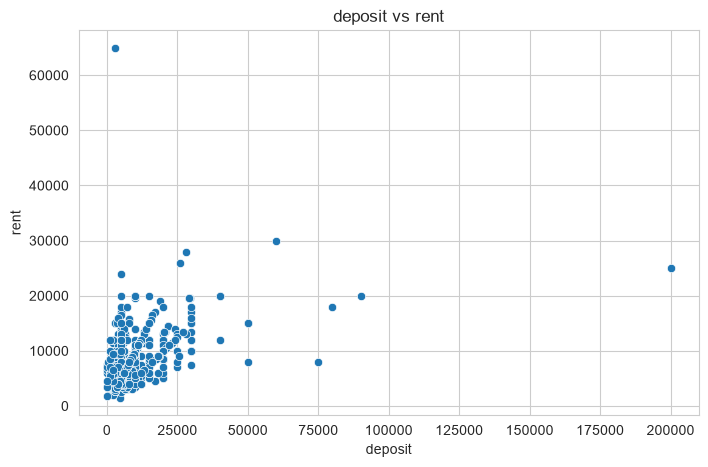

Pearson Correlation : 0.440


In [5]:
scatter_analysis(df, x='deposit', y='rent')

# Observation

- Moderate Correlation
- Premium PGs usually require higher deposits.

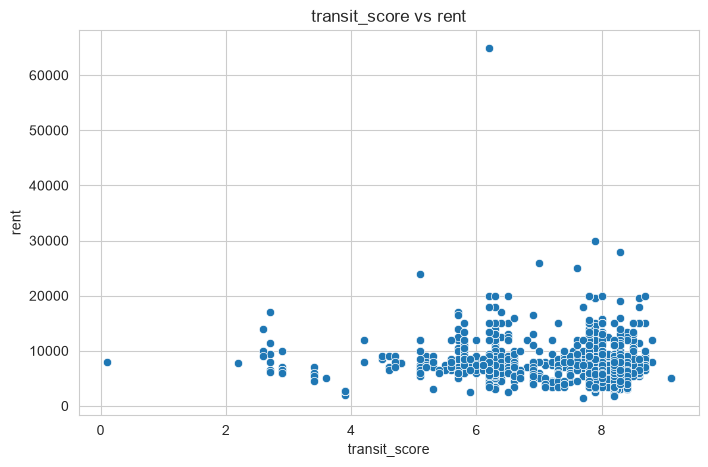

Pearson Correlation : -0.034


In [13]:
scatter_analysis(df, x='transit_score', y='rent')

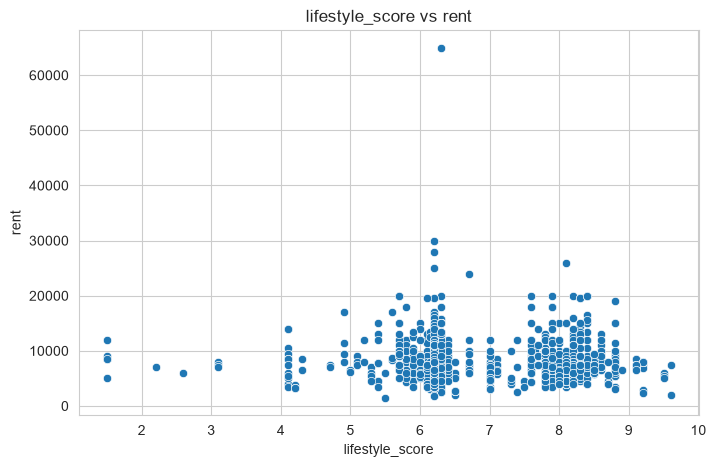

Pearson Correlation : 0.016


In [14]:
scatter_analysis(df, x='lifestyle_score', y='rent')

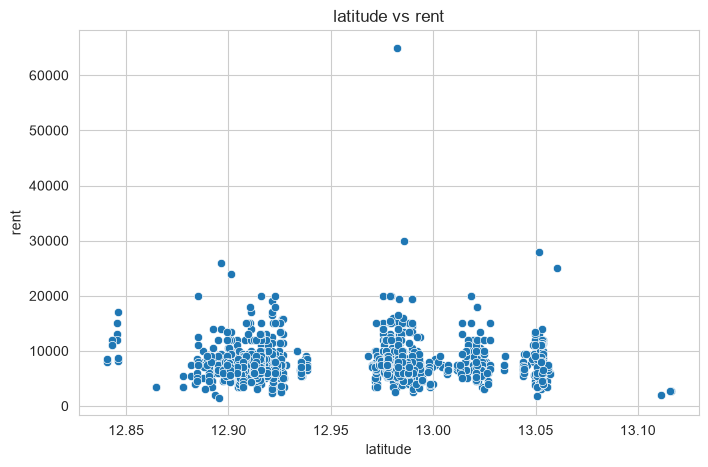

Pearson Correlation : 0.017


In [7]:
scatter_analysis(df, x='latitude', y='rent')

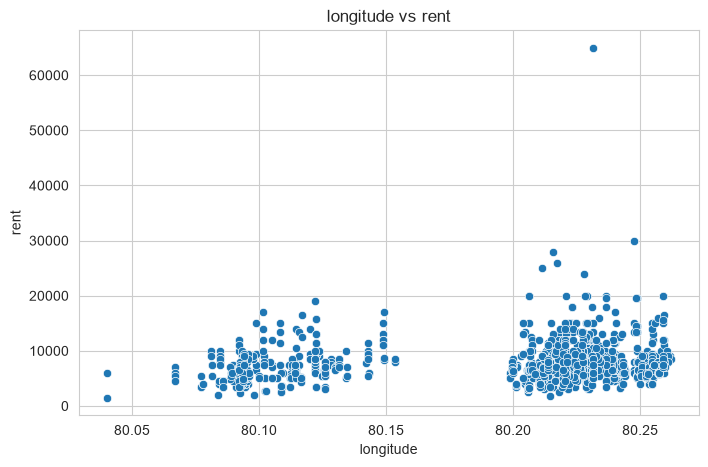

Pearson Correlation : 0.115


In [8]:
scatter_analysis(df, x='longitude', y='rent')

# 4.2 Correlation Matrix (nummeric columns)

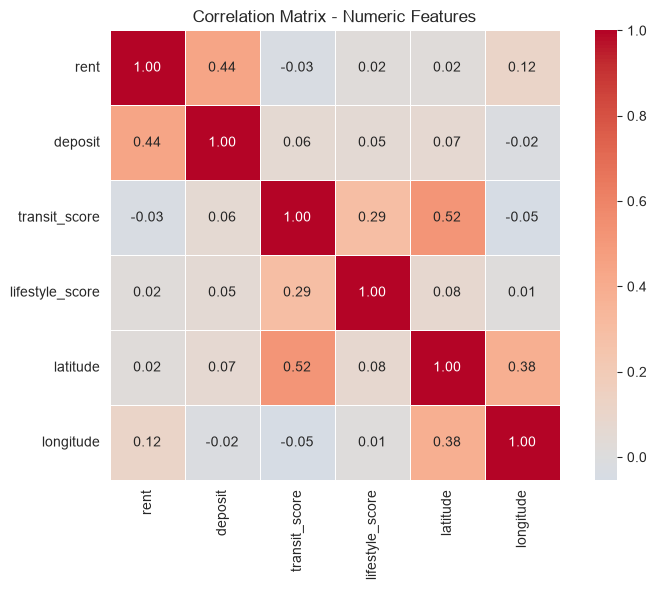

                     rent   deposit  transit_score  lifestyle_score  latitude  \
rent             1.000000  0.440126      -0.033944         0.016357  0.017373   
deposit          0.440126  1.000000       0.057622         0.053381  0.066963   
transit_score   -0.033944  0.057622       1.000000         0.294443  0.521451   
lifestyle_score  0.016357  0.053381       0.294443         1.000000  0.080833   
latitude         0.017373  0.066963       0.521451         0.080833  1.000000   
longitude        0.115268 -0.020252      -0.054436         0.013771  0.382760   

                 longitude  
rent              0.115268  
deposit          -0.020252  
transit_score    -0.054436  
lifestyle_score   0.013771  
latitude          0.382760  
longitude         1.000000  


In [6]:
# 4.1 Correlation Heatmap (numeric columns) closes the multicollinearity-check gap from the Phase 2 plan

numeric_cols = ['rent', 'deposit', 'transit_score', 'lifestyle_score', 'latitude', 'longitude']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

print(corr_matrix)

# Observation

- Deposit has the strongest positive correlation with rent.
- Transit and lifestyle scores show weak correlations.
- Latitude and longitude exhibit minimal linear correlation with rent.
- latitude <-> transit_score @52, so i have transit-score and lifestyle-score so, considering to drop lat&long

# 4.3 Categorical vs Rent

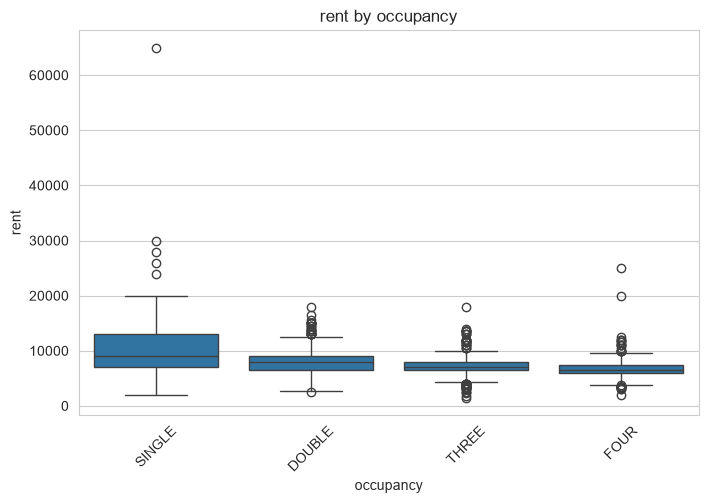

,count,mean,median
occupancy,,,
SINGLE,194,10626.546392,9000.0
DOUBLE,399,8143.458647,8000.0
THREE,476,7277.497899,7000.0
FOUR,402,6638.325871,6500.0


In [10]:
box_analysis(
    df,
    "occupancy",
    "rent"
)

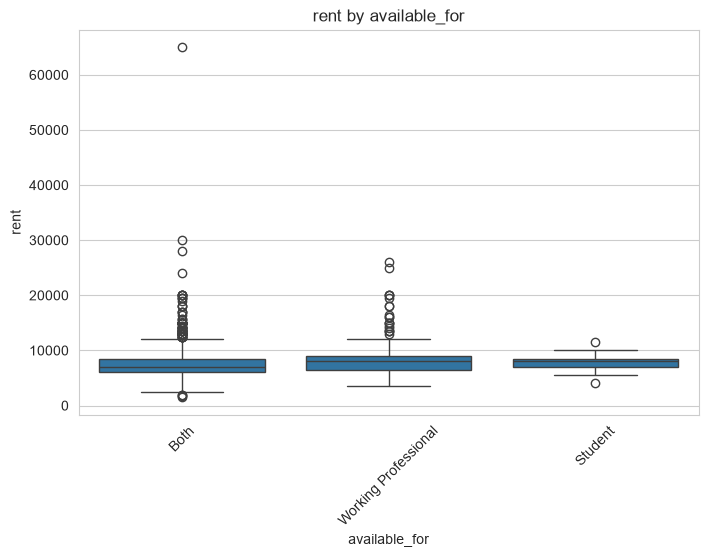

,count,mean,median
available_for,,,
Working Professional,139,8758.633094,8000.0
Student,25,7900.000000,8000.0
Both,1307,7672.942617,7000.0


In [11]:
box_analysis(
    df,
    "available_for",
    "rent"
)

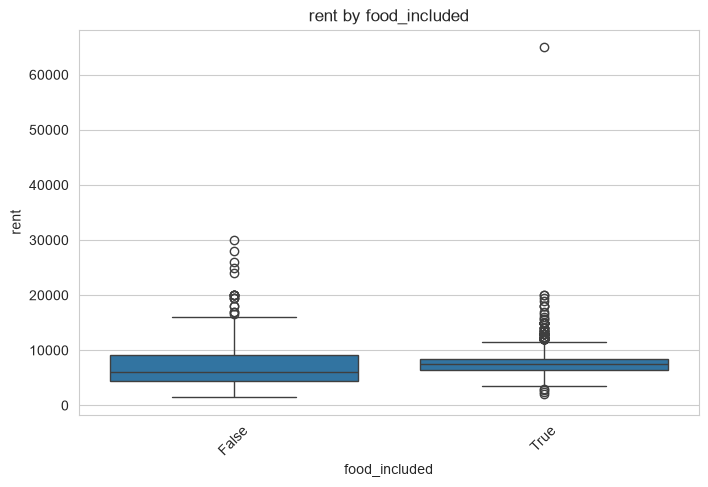

,count,mean,median
food_included,,,
True,1103,7887.534905,7500.0
False,368,7455.258152,6000.0


In [14]:
box_analysis(
    df,
    "food_included",
    "rent"
)

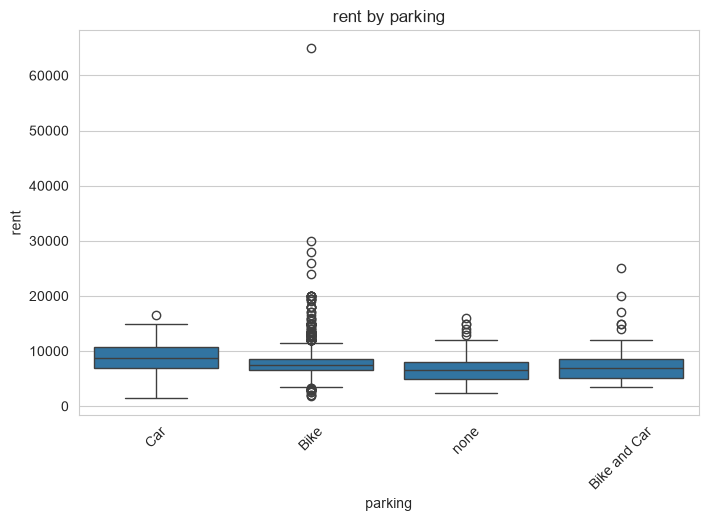

,count,mean,median
parking,,,
Car,48,9143.750000,8750.0
Bike,1170,7851.526496,7499.5
Bike and Car,109,7457.798165,7000.0
none,144,6981.944444,6500.0


In [7]:
box_analysis(
    df,
    "parking",
    "rent"
)

occupancy     DOUBLE   FOUR  SINGLE  THREE
parking                                   
Bike           0.269  0.280   0.118  0.332
Bike and Car   0.275  0.248   0.193  0.284
Car            0.292  0.146   0.250  0.312
none           0.278  0.278   0.160  0.285


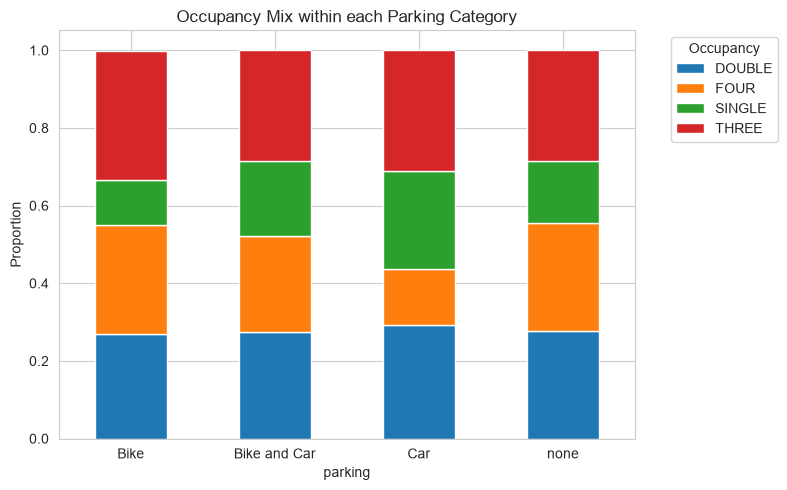

In [8]:
# 4.3 Parking x Occupancy confound check resolves the "Bike and Car" anomaly from 4.2

parking_occ = (
    df.groupby('parking')['occupancy']
    .value_counts(normalize=True)
    .unstack()
    .round(3)
)

print(parking_occ)

parking_occ.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Occupancy Mix within each Parking Category')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Occupancy', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

locality      Adambakkam  Adyar  Alandur  Arcot Road-Kodambakkam  Ashok Nagar  \
parking                                                                         
Bike               0.016  0.001    0.009                   0.017        0.006   
Bike and Car         NaN    NaN    0.028                     NaN          NaN   
Car                  NaN    NaN      NaN                     NaN          NaN   

locality      Balaji Nagar  East Coast Road-Thiruvanmiyur  East Tambaram  \
parking                                                                    
Bike                 0.010                          0.037          0.019   
Bike and Car         0.064                          0.138          0.073   
Car                    NaN                          0.021          0.083   

locality      GST Road-Tambaram  Guindy  ...   TNHB  Tambaram  \
parking                                  ...                    
Bike                      0.011    0.02  ...  0.001     0.038   
Bike and Car      

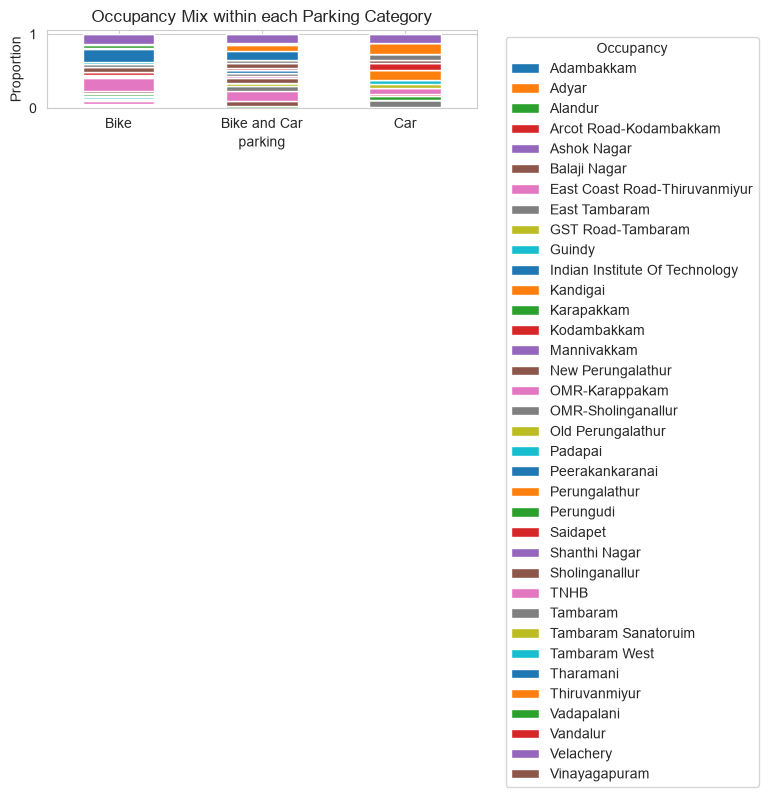

In [27]:
# 4.3 Parking x Occupancy confound check resolves the "Bike and Car" anomaly from 4.2

parking_occ = (
    df.groupby('parking')['locality']
    .value_counts(normalize=True)
    .unstack()
    .round(3)
)

print(parking_occ)

parking_occ.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Occupancy Mix within each Parking Category')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Occupancy', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [9]:
# 5.4 Does locality explain the parking anomaly? (weighted comparison, not eyeballing)

locality_means = df.groupby('locality')['rent'].mean()

parking_locality_mix = (
    df.groupby('parking')['locality']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

# "If locality were the only driver" — expected rent per parking category
expected_rent = (parking_locality_mix * locality_means).sum(axis=1)

actual_rent = df.groupby('parking')['rent'].mean()

comparison = pd.DataFrame({
    'expected_from_locality_mix': expected_rent.round(0),
    'actual_mean_rent': actual_rent.round(0)
})
comparison['residual'] = comparison['actual_mean_rent'] - comparison['expected_from_locality_mix']

print(comparison)

              expected_from_locality_mix  actual_mean_rent  residual
parking                                                             
Bike                              7813.0            7852.0      39.0
Bike and Car                      7686.0            7458.0    -228.0
Car                               7680.0            9144.0    1464.0
none                              7609.0            6982.0    -627.0


## Top 15 Localities

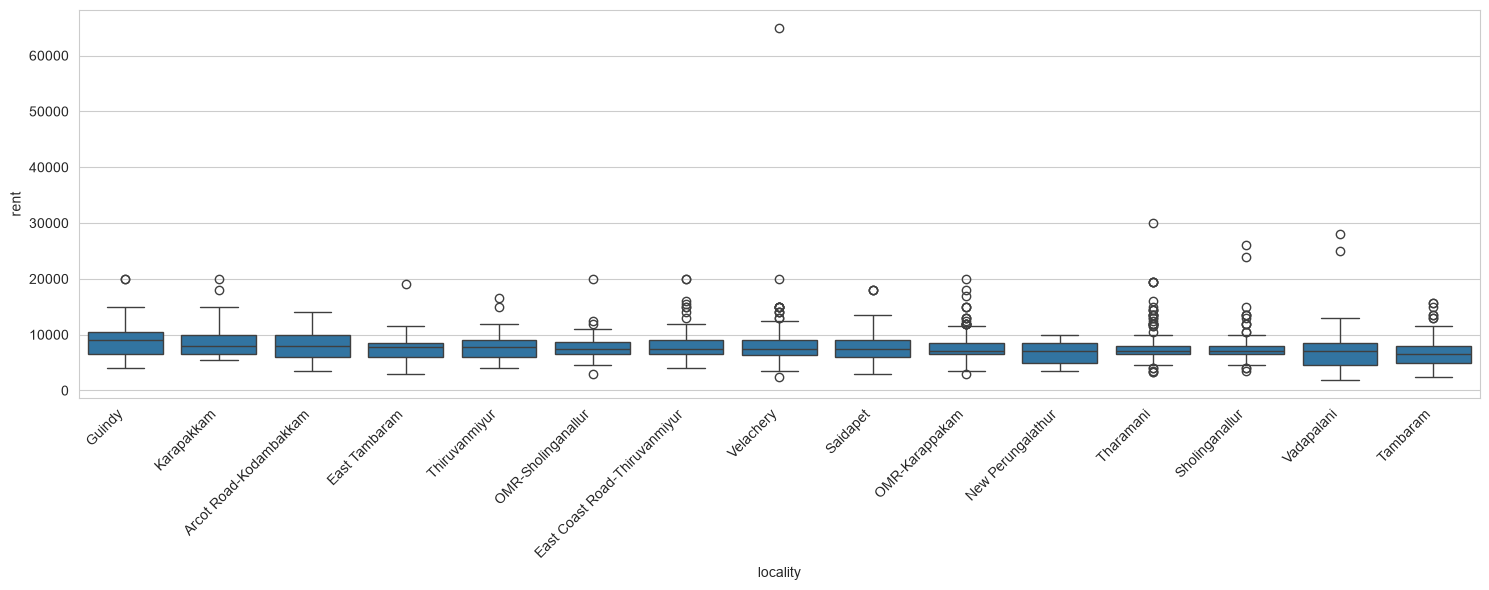

,Count,Mean,Median
locality,,,
Guindy,27,9548.148148,9000.0
Karapakkam,44,8804.545455,8000.0
East Coast Road-Thiruvanmiyur,63,8539.682540,7500.0
Velachery,192,8148.984375,7500.0
OMR-Sholinganallur,28,8125.000000,7500.0
Arcot Road-Kodambakkam,28,8007.142857,8000.0
Saidapet,61,7972.131148,7500.0
Sholinganallur,94,7939.148936,7000.0
Thiruvanmiyur,40,7935.000000,7750.0


In [10]:
top_localities = (
    df["locality"]
    .value_counts()
    .head(15)
    .index
)

temp = df[
    df["locality"].isin(top_localities)
]
order = (
    temp.groupby("locality")["rent"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(15,6))
sns.boxplot(
    data=temp,
    x="locality",
    y="rent",
    order=order
)

plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

display(temp.groupby("locality")["rent"].agg(Count="count",Mean="mean",Median="median").sort_values("Mean",ascending=False))

# 4.4 Confounding Checks

occupancy,DOUBLE,FOUR,SINGLE,THREE
parking,,,,
Bike,0.269231,0.280342,0.117949,0.332479
Bike and Car,0.275229,0.247706,0.192661,0.284404
Car,0.291667,0.145833,0.250000,0.312500
none,0.277778,0.277778,0.159722,0.284722


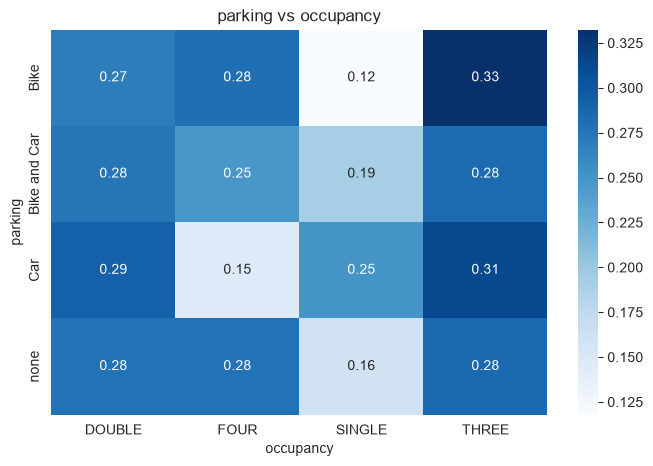

In [11]:
crosstab_analysis(
    df,
    "parking",
    "occupancy"
)

available_for,Both,Student,Working Professional
gender,,,
BOTH,0.725000,0.000000,0.275000
FEMALE,0.881997,0.025719,0.092284
MALE,0.902597,0.010390,0.087013


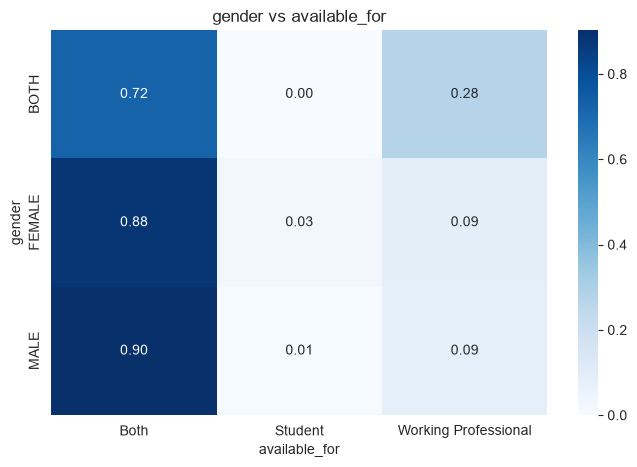

In [21]:
crosstab_analysis(
    df,
    "gender",
    "available_for"
)

In [22]:
top = df["locality"].value_counts().head(10).index

temp = df[df["locality"].isin(top)]

pd.crosstab(
    temp["locality"],
    temp["occupancy"],
    normalize="index"
)

occupancy,DOUBLE,FOUR,SINGLE,THREE
locality,,,,
East Coast Road-Thiruvanmiyur,0.222222,0.253968,0.142857,0.380952
Karapakkam,0.295455,0.250000,0.204545,0.250000
New Perungalathur,0.297872,0.297872,0.148936,0.255319
OMR-Karappakam,0.275862,0.262931,0.086207,0.375000
Saidapet,0.311475,0.229508,0.196721,0.262295
Sholinganallur,0.212766,0.297872,0.117021,0.372340
Tambaram,0.238095,0.317460,0.142857,0.301587
Tharamani,0.279167,0.275000,0.100000,0.345833
Vadapalani,0.222222,0.314815,0.166667,0.296296


# 4.5 Interaction Analysis

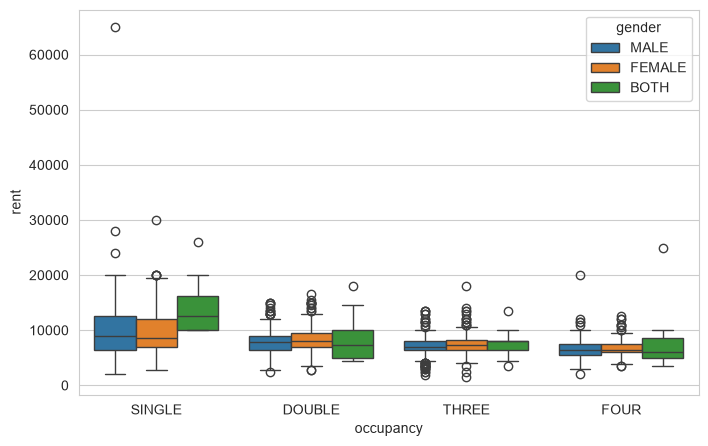

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="occupancy",
    y="rent",
    hue="gender"
)

plt.show()

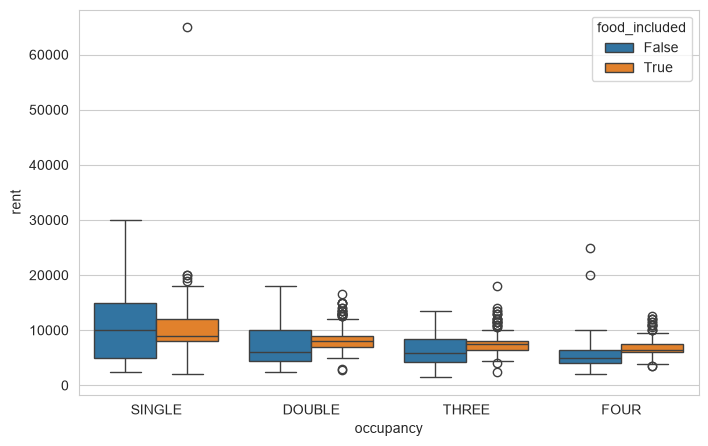

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="occupancy",
    y="rent",
    hue="food_included"

)

plt.show()

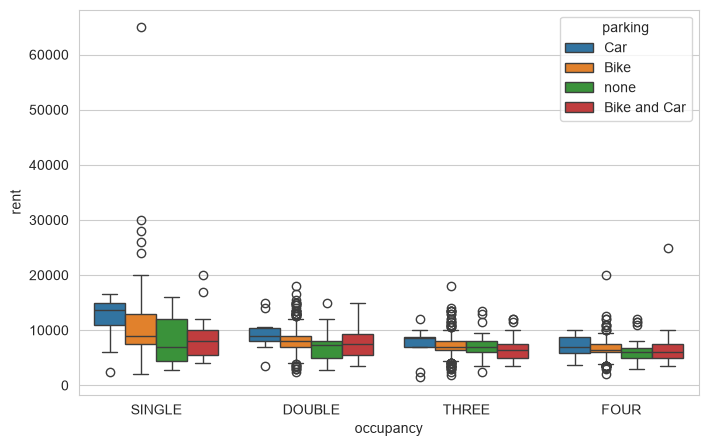

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="occupancy",
    y="rent",
    hue="parking"
)

plt.show()

# EDA Phase 4: Bivariate Analysis Report

> **Objective:** Analyze the relationship between each feature and the target (`rent`), identify important predictors, detect confounding effects, and document preprocessing decisions before feature engineering.

---

# 4.1 Numerical vs Rent

| Feature | Pearson Correlation | Interpretation |
|----------|--------------------:|----------------|
| Deposit | **0.44** | Moderate positive relationship |
| Transit Score | -0.03 | Negligible linear relationship |
| Lifestyle Score | 0.02 | Negligible linear relationship |
| Latitude | 0.02 | Negligible linear relationship |
| Longitude | 0.12 | Weak positive relationship |

### Observations

- **Deposit** is the strongest numerical predictor of rent.
- Higher-rent PGs generally require larger security deposits.
- Considerable spread exists at similar deposit values, indicating that rent is influenced by multiple factors rather than deposit alone.
- Transit score, lifestyle score, latitude and longitude show little direct linear relationship with rent.

### Decision

- Retain all numerical features.
- Deposit is a useful predictor.
- Weak Pearson correlation alone is **not sufficient reason** to remove transit or lifestyle scores, as they may still contribute through nonlinear relationships.

---

# 4.2 Correlation Matrix

### Key Findings

- Deposit remains the strongest numerical feature associated with rent.
- Transit score and latitude show a moderate positive correlation (**r ≈ 0.52**).
- Transit score and lifestyle score have a mild positive relationship.
- No pair of numerical variables exhibits severe multicollinearity.

### Decision

- Retain all numerical features.
- Note the moderate redundancy between transit score and latitude if linear models are later used.

---

# 4.3 Categorical Features vs Rent

## Occupancy

Average rent decreases consistently as room sharing increases.

| Occupancy | Mean Rent |
|-----------|----------:|
| Single | 10,627 |
| Double | 8,143 |
| Three | 7,277 |
| Four | 6,638 |

### Observation

Occupancy is the strongest categorical predictor of rent.

### Decision

Retain occupancy and preserve its natural ordering during encoding.

---

## Locality

Top localities show meaningful variation in rent.

Among high-volume localities, the average rent differs by almost ₹2,800 between the highest and lowest priced areas.

### Observation

Location contributes significant pricing information beyond occupancy.

### Decision

Retain locality.

Proceed with the planned smoothed target encoding because of the long-tail distribution identified in Phase 3.

---

## Available For

Working Professional listings exhibit the highest average rent.

However, nearly 89% of listings belong to the **Both/Anyone** category.

### Observation

Although heavily imbalanced, the feature still shows meaningful differences in rent.

### Decision

Retain the feature and monitor its usefulness during modeling.

---

## Food Included

Food-inclusive PGs charge approximately ₹400 more on average.

### Observation

Food has a small but consistent positive association with rent.

### Decision

Retain as a minor predictive feature.

---

## Parking

Raw averages suggest:

Car > Bike > Bike & Car

However, these differences require confounding analysis before interpretation.

---

# 4.4 Confounding Analysis

## Parking × Occupancy

The apparent parking premium is partly explained by occupancy.

Car parking listings contain a much larger proportion of Single occupancy rooms, which naturally command higher rents.

### Observation

Parking itself is not solely responsible for higher rent.

Occupancy explains a substantial portion of the observed parking effect.

### Decision

Retain parking as a separate feature.

Do not collapse parking into a binary variable.

---

## Gender × Available For

Mixed-gender (BOTH) PGs contain a much higher proportion of Working Professional listings.

### Observation

The higher average rent observed for BOTH-gender PGs is partially explained by the Working Professional composition rather than gender alone.

### Decision

Interpret the gender effect cautiously.

Retain both features.

---

## Locality × Occupancy

Occupancy distributions vary only moderately across major localities.

No locality exhibits an extreme occupancy imbalance.

### Decision

No preprocessing action required.

---

# 4.5 Interaction Analysis

Three interaction plots were examined.

- Occupancy × Gender
- Occupancy × Food Included
- Occupancy × Parking

### Observation

The overall occupancy trend remains consistent across all interaction plots.

Single-sharing rooms consistently command the highest rents regardless of gender, food availability or parking category.

No interaction indicates a complete reversal of the occupancy–rent relationship.

---

# Phase 4 Summary

## Strong Predictors

- Occupancy
- Deposit
- Locality

## Moderate Predictors

- Available For
- Parking
- Food Included

## Weak Linear Predictors

- Transit Score
- Lifestyle Score
- Latitude
- Longitude

## Important Findings

- Occupancy is the strongest categorical driver of rent.
- Deposit is the strongest numerical predictor.
- Locality contributes meaningful pricing information despite its long-tail distribution.
- Parking effects are partially explained by occupancy.
- Mixed-gender PGs appear more expensive largely because they contain more Working Professional listings.
- No severe multicollinearity was detected.

---

# Phase 4 Decisions

| # | Decision | Status |
|---|----------|--------|
| 1 | Retain all numerical features | ✅ |
| 2 | Keep occupancy as an ordered categorical feature | ✅ |
| 3 | Retain locality for smoothed target encoding | ✅ |
| 4 | Keep parking as four categories | ✅ |
| 5 | Retain available_for despite class imbalance | ✅ |
| 6 | Treat transit score and latitude as moderately correlated during modeling | ✅ |
| 7 | Delay feature selection until model-based evaluation | ✅ |

---

> **Next:** Phase 5 – Multivariate Analysis, focusing on interaction effects, feature importance, and validating which variables remain useful when considered together.